# 1 · Getting started with `bandsolver`

`bandsolver` is an implementation of John Newman's **BAND** method (*Electrochemical Systems*, 3rd ed., Appendix C) for systems of coupled, nonlinear, one-dimensional differential equations: steady boundary-value problems, and the equations of each implicit time step of a transient problem. It has two interchangeable native cores, C++17 and Fortran 2008, and both are reachable from Python.

This notebook covers:

1. what problem BAND solves and what its block structure looks like;
2. solving a linear block system directly with `bs.solve`;
3. solving a **nonlinear** boundary-value problem with Newton's method (`bs.newton`), using a hand-written Jacobian;
4. letting the library build the Jacobian by finite differences (`bs.newton_fd`) and checking a hand-written one (`bs.check_jacobian`);
5. confirming second-order spatial accuracy.

The next two notebooks apply the same pattern to coupled PDE systems from electrochemistry: [a binary electrolyte](02_binary_electrolyte.ipynb) and [a porous electrode](03_porous_electrode.ipynb).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bandsolver as bs

# Plot style: categorical colours in fixed order, an ordinal blue ramp for time series,
# neutral ink for text, thin marks and a recessive grid.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]   # light -> dark
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "lines.markersize": 6, "legend.frameon": False,
    "figure.dpi": 110, "font.size": 10, "axes.titlesize": 11,
})
print("bandsolver", bs.__version__, "| backends:", bs.BACKENDS)

bandsolver 0.1.0 | backends: ('cpp', 'fortran')


## The problem BAND solves

Discretize a system of $n$ coupled equations on $n_j$ mesh points. At node $j$ the unknowns form a vector $\mathbf c_j\in\mathbb R^n$, and the discrete equations at node $j$ involve only the node and its two neighbours:

$$
\mathbf F_j(\mathbf c_{j-1},\,\mathbf c_j,\,\mathbf c_{j+1}) = \mathbf 0, \qquad j = 0,\dots,n_j-1 .
$$

Newton's method linearizes about the current iterate $\mathbf c$ and solves for a correction $\Delta\mathbf c$:

$$
\mathsf A_j\,\Delta\mathbf c_{j-1} + \mathsf B_j\,\Delta\mathbf c_j + \mathsf D_j\,\Delta\mathbf c_{j+1} = \mathbf G_j,
\qquad
\mathsf A_j = \frac{\partial \mathbf F_j}{\partial \mathbf c_{j-1}},\;
\mathsf B_j = \frac{\partial \mathbf F_j}{\partial \mathbf c_{j}},\;
\mathsf D_j = \frac{\partial \mathbf F_j}{\partial \mathbf c_{j+1}},\;
\mathbf G_j = -\mathbf F_j(\mathbf c),
$$

and updates $\mathbf c \leftarrow \mathbf c + \Delta\mathbf c$. The $n\times n$ blocks make the global matrix **block tridiagonal**. The two boundary equations may also reach one node further, which is needed for second-order one-sided boundary conditions. That coupling is carried by two extra blocks:

$$
\mathsf X = \frac{\partial \mathbf F_0}{\partial \mathbf c_2},\qquad \mathsf Y = \frac{\partial \mathbf F_{n_j-1}}{\partial \mathbf c_{n_j-3}} .
$$

BAND eliminates node by node, writing $\Delta\mathbf c_j = \mathsf E_j\,\Delta\mathbf c_{j+1} + \mathbf e_j$, and then back-substitutes. The cost is $O(n_j\,n^3)$ time and $O(n_j\,n^2)$ memory, so it is linear in the number of mesh points.

**Array conventions in Python.** `A, B, D` have shape `(nj, n, n)`, where `A[j][i, k]` couples equation `i` at node `j` to unknown `k` at node `j-1`. `G` and the state `c` have shape `(nj, n)`, and `X, Y` have shape `(n, n)`. `A[0]` and `D[nj-1]` are ignored.

## 1. A linear block system

We start with a random, well-conditioned system with $n=2$ unknowns per node, $n_j=8$ nodes, and nonzero endpoint blocks $\mathsf X,\mathsf Y$. We solve it with both backends and compare against a dense solve of the assembled matrix $\mathsf K$.

In [2]:
rng = np.random.default_rng(0)
n, nj = 2, 8
A = rng.uniform(-1, 1, (nj, n, n))
B = rng.uniform(-1, 1, (nj, n, n)) + 4 * np.eye(n)
D = rng.uniform(-1, 1, (nj, n, n))
G = rng.uniform(-1, 1, (nj, n))
X = rng.uniform(-1, 1, (n, n))
Y = rng.uniform(-1, 1, (n, n))

def assemble(A, B, D, X, Y):
    """Dense K, for illustration only; BAND never forms it."""
    nj, n, _ = B.shape
    K = np.zeros((nj * n, nj * n))
    for j in range(nj):
        r = slice(j * n, (j + 1) * n)
        K[r, j * n:(j + 1) * n] = B[j]
        if j > 0:
            K[r, (j - 1) * n:j * n] = A[j]
        if j < nj - 1:
            K[r, (j + 1) * n:(j + 2) * n] = D[j]
    K[0:n, 2 * n:3 * n] += X
    K[-n:, -3 * n:-2 * n] += Y
    return K

K = assemble(A, B, D, X, Y)
ref = np.linalg.solve(K, G.ravel()).reshape(nj, n)
for backend in bs.BACKENDS:
    dc = bs.solve(A, B, D, G, X, Y, backend=backend)
    print(f"{backend:8s} max |dc - dense| = {np.abs(dc - ref).max():.1e}")

cpp      max |dc - dense| = 5.6e-17
fortran  max |dc - dense| = 5.6e-17


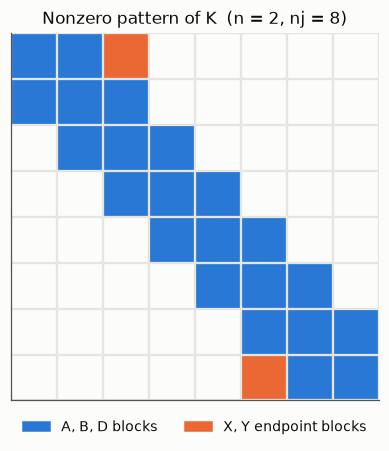

In [3]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# 0 = zero, 1 = A/B/D (block tridiagonal), 2 = X/Y (second-neighbour endpoint blocks)
kind = (K != 0).astype(float)
kind[0:n, 2 * n:3 * n] = 2
kind[-n:, -3 * n:-2 * n] = 2
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.imshow(np.ma.masked_where(kind == 0, kind), cmap=ListedColormap([BLUE, ORANGE]), vmin=1, vmax=2,
          interpolation="nearest")
ax.set_xticks(np.arange(-0.5, nj * n, n), minor=True)
ax.set_yticks(np.arange(-0.5, nj * n, n), minor=True)
ax.grid(which="minor", color=GRID, linewidth=1.5)
ax.grid(which="major", visible=False)
ax.tick_params(which="both", length=0)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Nonzero pattern of K  (n = 2, nj = 8)")
ax.legend(handles=[Patch(color=BLUE, label="A, B, D blocks"), Patch(color=ORANGE, label="X, Y endpoint blocks")],
          loc="upper right", bbox_to_anchor=(1.0, -0.02), ncol=2, fontsize=9)
fig.tight_layout(); plt.show()

Each grid cell is one $2\times2$ block. The main diagonal holds $\mathsf B_j$; directly beside it are $\mathsf A_j$ (left) and $\mathsf D_j$ (right). The two isolated blocks in the corners are $\mathsf X$ and $\mathsf Y$, the second-neighbour boundary coupling that Appendix C allows.

## 2. A nonlinear boundary-value problem

Consider steady diffusion with a concentration-dependent diffusivity:

$$
-\frac{d}{dx}\!\left(\mathcal D(c)\,\frac{dc}{dx}\right) = f(x),\qquad \mathcal D(c) = 1 + c^2,\qquad c(0)=c(1)=0 .
$$

We choose $f$ so that the exact solution is $c^\ast(x)=\sin\pi x$ (a *manufactured solution*):

$$
f = -\left(\mathcal D'(c^\ast)\,(c^{\ast\prime})^2 + \mathcal D(c^\ast)\,c^{\ast\prime\prime}\right).
$$

### Discretization

Use $n_j$ equally spaced nodes $x_j = jh$ and a conservative finite-volume form. The diffusivity is evaluated at the faces $j\pm\tfrac12$ using the mean concentration there:

$$
F_j = -\frac{\mathcal D_{j+\frac12}\,(c_{j+1}-c_j) - \mathcal D_{j-\frac12}\,(c_j-c_{j-1})}{h^2} - f_j,
\qquad
\mathcal D_{j\pm\frac12} = \mathcal D\!\left(\tfrac{c_j + c_{j\pm1}}{2}\right).
$$

Differentiating gives the three $1\times1$ Jacobian blocks. Write $\Delta_\pm = \pm(c_{j\pm1}-c_j)$ and $\mathcal D'_\pm = \mathcal D'(c_{j\pm\frac12})$:

$$
A_j = \frac{\tfrac12\mathcal D'_-\,\Delta_- - \mathcal D_{j-\frac12}}{h^2},\qquad
D_j = -\frac{\mathcal D_{j+\frac12} + \tfrac12\mathcal D'_+\,\Delta_+}{h^2},\qquad
B_j = \frac{\mathcal D_{j+\frac12} + \mathcal D_{j-\frac12} - \tfrac12\mathcal D'_+\Delta_+ + \tfrac12\mathcal D'_-\Delta_-}{h^2}.
$$

At the boundaries the equation is simply $F_0 = c_0$ and $F_{n_j-1} = c_{n_j-1}$, so $B=1$ there.

The **fill function** you pass to `bs.newton` receives the current state `c` (shape `(nj, 1)`). It returns `(A, B, D, G)` with $\mathbf G = -\mathbf F$, and everything is vectorized with numpy.

In [4]:
def source(x):
    s, sx, sxx = np.sin(np.pi * x), np.pi * np.cos(np.pi * x), -np.pi**2 * np.sin(np.pi * x)
    return -(2 * s * sx**2 + (1 + s**2) * sxx)

def fill(c):
    nj = c.shape[0]
    u, h = c[:, 0], 1.0 / (nj - 1)
    x = np.linspace(0, 1, nj)
    A = np.zeros((nj, 1, 1)); B = np.zeros((nj, 1, 1)); D = np.zeros((nj, 1, 1)); G = np.zeros((nj, 1))
    i = np.arange(1, nj - 1)                       # interior nodes
    cm, cp = (u[i] + u[i - 1]) / 2, (u[i] + u[i + 1]) / 2
    Dm, Dp = 1 + cm**2, 1 + cp**2                  # D at the faces j-1/2, j+1/2
    dDm, dDp = 2 * cm, 2 * cp                      # D'(c) at the faces
    F = -(Dp * (u[i + 1] - u[i]) - Dm * (u[i] - u[i - 1])) / h**2 - source(x[i])
    G[i, 0] = -F
    A[i, 0, 0] = (0.5 * dDm * (u[i] - u[i - 1]) - Dm) / h**2
    D[i, 0, 0] = -(Dp + 0.5 * dDp * (u[i + 1] - u[i])) / h**2
    B[i, 0, 0] = (Dp + Dm - 0.5 * dDp * (u[i + 1] - u[i]) + 0.5 * dDm * (u[i] - u[i - 1])) / h**2
    B[0, 0, 0] = B[-1, 0, 0] = 1.0                 # boundary rows: F = c
    G[0, 0], G[-1, 0] = -u[0], -u[-1]
    return A, B, D, G

### Newton's method

`bs.newton(fill, c0)` repeats *fill → BAND solve → update* until the correction is small:

$$
\max_{i,j}\ \frac{|\Delta c_{ij}|}{\text{atol} + \text{rtol}\,|c_{ij}|} \le 1 \qquad(\text{defaults } \text{rtol}=10^{-10},\ \text{atol}=10^{-12}).
$$

It returns the solution together with a record of every iteration. Close to the solution, Newton's method converges **quadratically**: each correction is roughly the square of the previous one.

converged=True in 6 iterations
step norms max|dc|: 1.3e+00  2.8e-01  4.8e-02  1.2e-03  6.9e-07  2.4e-13
max error vs sin(pi x): 1.10e-04


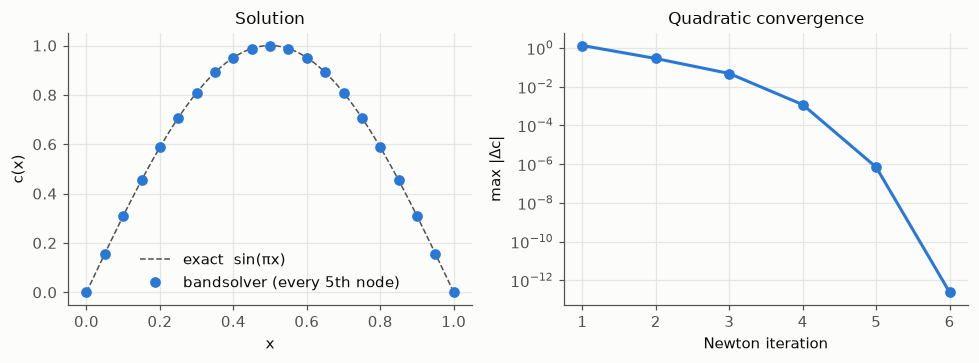

In [5]:
nj = 101
x = np.linspace(0, 1, nj)
res = bs.newton(fill, np.zeros((nj, 1)))
print(f"converged={res.converged} in {res.iterations} iterations")
print("step norms max|dc|:", "  ".join(f"{s:.1e}" for s in res.step_norm))
print(f"max error vs sin(pi x): {np.abs(res.c[:, 0] - np.sin(np.pi * x)).max():.2e}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))
ax1.plot(x, np.sin(np.pi * x), color=INK2, linewidth=1, linestyle="--", label="exact  sin(πx)")
ax1.plot(x[::5], res.c[::5, 0], "o", color=BLUE, label="bandsolver (every 5th node)")
ax1.set_xlabel("x"); ax1.set_ylabel("c(x)"); ax1.set_title("Solution"); ax1.legend()
k = np.arange(1, res.iterations + 1)
ax2.semilogy(k, res.step_norm, "o-", color=BLUE)
ax2.set_xlabel("Newton iteration"); ax2.set_ylabel("max |Δc|"); ax2.set_title("Quadratic convergence")
fig.tight_layout(); plt.show()

The step sizes go $4.8\times10^{-2}\to1.2\times10^{-3}\to6.9\times10^{-7}\to2.4\times10^{-13}$: once the iterate is close, the number of correct digits doubles every iteration. That is the signature of a correct Jacobian. A wrong Jacobian usually still converges, but only linearly, so this plot is a useful diagnostic.

## 3. Letting the library build the Jacobian

Deriving the blocks by hand is error-prone. Appendix C suggests computing them by finite differences, which the library does in `bs.newton_fd`: **you only write the residual $\mathbf F(\mathbf c)$.**

Every equation involves at most three consecutive nodes, so perturbing unknown $k$ at every third node *simultaneously* separates all the derivatives. One Jacobian therefore costs only

$$
3n + 1 \ \text{residual evaluations, independent of } n_j .
$$

The fill function above already computes $\mathbf G=-\mathbf F$, so the residual is simply `-fill(c)[3]`. In a real code you would write the residual directly and skip the Jacobian.

In [6]:
residual = lambda c: -fill(c)[3]
res_fd = bs.newton_fd(residual, np.zeros((nj, 1)))
print(f"newton_fd: {res_fd.iterations} iterations, {res_fd.residual_evaluations} residual calls "
      f"(= (3n+1) x iterations = 4 x {res_fd.iterations})")
print(f"max |c_fd - c_analytic_jacobian| = {np.abs(res_fd.c - res.c).max():.1e}")

newton_fd: 6 iterations, 24 residual calls (= (3n+1) x iterations = 4 x 6)
max |c_fd - c_analytic_jacobian| = 1.1e-16


If you do write a Jacobian by hand, whether for speed or to use analytic derivatives, **check it**. `bs.check_jacobian(fill, c)` differentiates the fill's own $\mathbf G$ and reports the worst mismatch in each block.

We test two common mistakes:

- **"forgot ½"**: the factor $\tfrac12$ is dropped from the $\mathcal D'$ term of $\mathsf D_j$;
- **"frozen coefficient"**: the $\mathcal D'(c)$ terms are left out entirely, i.e. the diffusivity is treated as constant when differentiating. This is a popular shortcut.

In [7]:
c_test = np.sin(np.pi * x)[:, None] * 0.8

def forgot_half_fill(c):
    A, B, D, G = fill(c)
    u, h = c[:, 0], 1.0 / (c.shape[0] - 1)
    i = np.arange(1, c.shape[0] - 1)
    cp = (u[i] + u[i + 1]) / 2
    D = D.copy()
    D[i, 0, 0] -= 0.5 * 2 * cp * (u[i + 1] - u[i]) / h**2      # D' term now counted twice
    return A, B, D, G

def frozen_fill(c):
    A, B, D, G = fill(c)
    u, h = c[:, 0], 1.0 / (c.shape[0] - 1)
    i = np.arange(1, c.shape[0] - 1)
    cm, cp = (u[i] + u[i - 1]) / 2, (u[i] + u[i + 1]) / 2
    A, B, D = A.copy(), B.copy(), D.copy()
    A[i, 0, 0] = -(1 + cm**2) / h**2                           # D'(c) terms dropped
    D[i, 0, 0] = -(1 + cp**2) / h**2
    B[i, 0, 0] = (2 + cm**2 + cp**2) / h**2
    return A, B, D, G

for name, f in [("correct", fill), ("forgot 1/2", forgot_half_fill), ("frozen coefficient", frozen_fill)]:
    block, m = bs.check_jacobian(f, c_test).worst()
    print(f"{name:19s} score {m.error:8.1e}   worst: block {block}, node {m.node}, "
          f"user {m.user:.5g} vs finite difference {m.fd:.5g}")

correct             score  7.3e-09   worst: block D, node 59, user -15789 vs finite difference -15789
forgot 1/2          score  7.9e-03   worst: block D, node 78, user -12305 vs finite difference -12403
frozen coefficient  score  7.8e-03   worst: block A, node 22, user -12501 vs finite difference -12403


A correct Jacobian scores around $10^{-9}$. Both mistakes score about $10^{-2}$. That looks small, because the faulty $\mathcal D'$ terms are a small part of entries dominated by $\mathcal D/h^2$. But it is **six orders of magnitude above** the correct Jacobian's score, and anything above about $10^{-3}$ indicates a bug.

What does such a "small" error cost? The next cell runs Newton with each Jacobian, stopping after 14 iterations whether or not it has converged.

correct             converged=True  iterations=6
frozen coefficient  converged=True  iterations=12
forgot 1/2          converged=False iterations=14


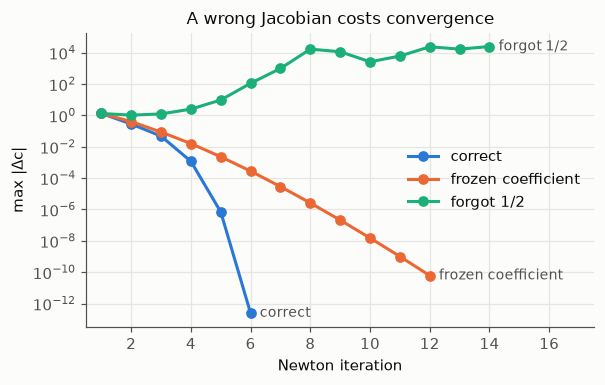

In [8]:
runs = {}
for name, f in [("correct", fill), ("frozen coefficient", frozen_fill), ("forgot 1/2", forgot_half_fill)]:
    with np.errstate(over="ignore", invalid="ignore"):
        r = bs.newton(f, np.zeros((nj, 1)), max_iter=14, require_convergence=False)
    runs[name] = r.step_norm
    print(f"{name:19s} converged={r.converged!s:5s} iterations={r.iterations}")

fig, ax = plt.subplots(figsize=(5.6, 3.6))
for (name, steps), color in zip(runs.items(), [BLUE, ORANGE, AQUA]):
    k = np.arange(1, len(steps) + 1)
    ax.semilogy(k, steps, "o-", color=color, label=name)
    ax.annotate(name, xy=(k[-1], steps[-1]), xytext=(6, 0), textcoords="offset points",
                va="center", color=INK2, fontsize=9)
ax.set_xlabel("Newton iteration"); ax.set_ylabel("max |Δc|")
ax.set_title("A wrong Jacobian costs convergence")
ax.set_xlim(0.5, 17.5); ax.legend(loc="center right"); fig.tight_layout(); plt.show()

The correct Jacobian converges **quadratically** in 6 iterations. The frozen-coefficient Jacobian still converges, but only **linearly** (about one digit per iteration). The "forgot ½" bug makes Newton **diverge**. Left to run, it overflows, and `bs.newton` then raises a `NonFiniteError` rather than returning garbage. `check_jacobian` finds both problems before they cost you a debugging session.

## 4. Grid convergence

Finally, a refinement study confirms the expected $O(h^2)$ accuracy of the discretization.

nj=  21  max error 2.750e-03  observed order nan
nj=  41  max error 6.859e-04  observed order 2.003
nj=  81  max error 1.714e-04  observed order 2.001
nj= 161  max error 4.284e-05  observed order 2.000
nj= 321  max error 1.071e-05  observed order 2.000


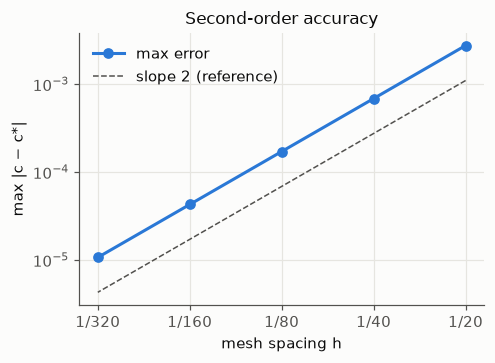

In [9]:
grids = [21, 41, 81, 161, 321]
errs = []
for m in grids:
    xm = np.linspace(0, 1, m)
    r = bs.newton(fill, np.zeros((m, 1)))
    errs.append(np.abs(r.c[:, 0] - np.sin(np.pi * xm)).max())
hs = 1.0 / (np.array(grids) - 1)
orders = np.log2(np.array(errs[:-1]) / np.array(errs[1:]))
for m, e, o in zip(grids, errs, [np.nan] + list(orders)):
    print(f"nj={m:4d}  max error {e:.3e}  observed order {o:.3f}")

fig, ax = plt.subplots(figsize=(4.6, 3.4))
ax.loglog(hs, errs, "o-", color=BLUE, label="max error")
ax.loglog(hs, 0.4 * errs[0] * (hs / hs[0])**2, color=INK2, linewidth=1, linestyle="--", label="slope 2 (reference)")
ax.set_xticks(hs, [f"1/{m - 1}" for m in grids]); ax.minorticks_off()
ax.set_xlabel("mesh spacing h"); ax.set_ylabel("max |c − c*|"); ax.set_title("Second-order accuracy")
ax.legend(); fig.tight_layout(); plt.show()

## Where next

- [**2 · Binary electrolyte**](02_binary_electrolyte.ipynb): transient Nernst–Planck transport with two coupled unknowns (concentration and potential), implicit time stepping, validated against an analytic solution.
- [**3 · Porous electrode**](03_porous_electrode.ipynb): the Newman–Tobias current distribution with Butler–Volmer kinetics, solved from the residual alone.
- Fortran and C++ users: see `examples/fortran_quickstart.f90`, `examples/cpp_quickstart.cpp`, and `docs/api.md`.